In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opt_einsum as oe
import sys
sys.path.append('/Users/afiorent/hydro_glasses/')
from time import time
from ase.io import read,write
from ase import units
from hydro_glasses import lanczos,test_lanczos
from hydro_glasses import amorphous_tools as at
import logging
import os
from scipy import sparse
#multiprocessing
from multiprocessing import Pool


In [2]:
def DHO(w, w0, sigma, norm):
    return norm*(w*2*sigma/((w*sigma)**2 + (w**2-w0**2)**2))
def wDHO(w, w0, sigma):
    return w**2*2*sigma/((w*sigma)**2 + (w**2-w0**2)**2)
def gauss(x,sigma):
    return np.exp(-((x) ** 2) / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))
def lorenztian(x,eta):
    return eta/np.pi/((x)**2+eta**2)
def compute_vdos(frequencies,freq_range, sigma,kernel='lorentz'):
    """
    Compute the vibrational density of states (VDOS) using a Gaussian kernel.

    Parameters:
    - frequencies: array-like
        List of angular frequencies (rad/s).
    - sigma: float
        Standard deviation of the Gaussian kernel.
    - freq_range: numpy array
        Frequency range over which the VDOS is computed.
    -kernel: str
        The kind of kernel used to compute the VDOS. Default is Lorentzian

    Returns:
    - vdos: numpy array
        Vibrational density of states.
    """
#     # Define the frequency range for the VDOS calculation
#     freq_min = np.min(frequencies) - 3 * sigma
#     freq_max = np.max(frequencies) + 3 * sigma
#     freq_range = np.linspace(freq_min, freq_max, bins)

    # Initialize the VDOS array
    vdos = np.zeros_like(freq_range)

    # Compute the kernel contribution from each frequency
    if kernel=='lorentz':
        for freq in frequencies:
            vdos += lorenztian((freq_range - freq),sigma)
    elif kernel=='DHO':
        for freq in frequencies:
            vdos += wDHO(freq_range,freq,sigma)
    else:
        for freq in frequencies:
            vdos += gauss((freq_range - freq),sigma)

    # Normalize the VDOS
    vdos /= np.trapz(vdos, freq_range)

    return  vdos


# Load sparse dynamical matrix

In [3]:
root='aSiO2_648/'
dynmat_sparse=sparse.load_npz(root+'dynmat.npz')
dynmat_sparse=(dynmat_sparse+dynmat_sparse.transpose())/2 #sometimes it is not symmetrical for numerical reasons
atoms=read(root+'replicated_atoms.xyz')
natoms=atoms.get_global_number_of_atoms()


In [5]:
eta=1
k=300
nstoc=10
spectrum={}
omega_array=np.linspace(0.1,300,10000)
spectrum['omega']=omega_array
phi=np.random.normal(size=natoms*3*nstoc).reshape([nstoc,3*natoms])
phi_norm=np.linalg.norm(phi,axis=1)
phi=phi/phi_norm[:,np.newaxis]

ncpus=os.cpu_count()
print('ncpus:',ncpus)
if ncpus>20:
    ncpus=12
start=time()
with Pool(ncpus) as p:
    inputs = [(dynmat_sparse,phi_,k,omega_array,eta,True) for phi_ in phi ]
    result = p.starmap(lanczos.spectrum, inputs)
end=time()

ncpus: 4


In [6]:
#saving
result=np.array(result,dtype='object')
for i in range(nstoc):
    spectrum[i]={}
    spectrum[i]['S']=result[i][0]
    spectrum[i]['alpha']=result[i][1]
    spectrum[i]['beta']=result[i][2]

np.save(root+'spectrum_k{}_eta{}.npy'.format(k,eta),spectrum)

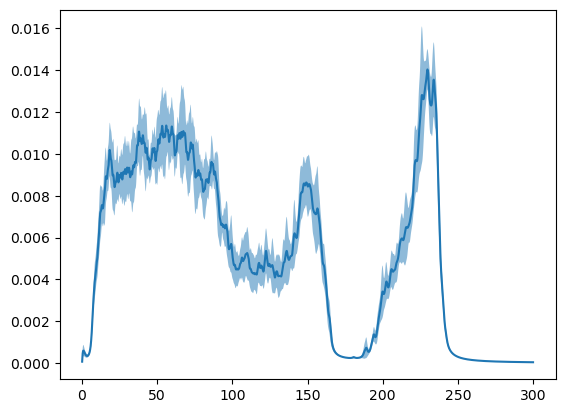

In [7]:
fig,ax=plt.subplots()
w=spectrum['omega']
y=np.mean(np.array([w*spectrum[i]['S'] for i in range(nstoc)]),axis=0)
yerr=np.std(np.array([w*spectrum[i]['S'] for i in range(nstoc)]),axis=0)
ax.plot(w,y)
ax.fill_between(w,y+yerr,y-yerr,alpha=0.5)
plt.show()


# Comparison haydock vs direct method

In [8]:
dynmat_dense=dynmat_sparse.toarray()
w2,eig=np.linalg.eigh(dynmat_dense)


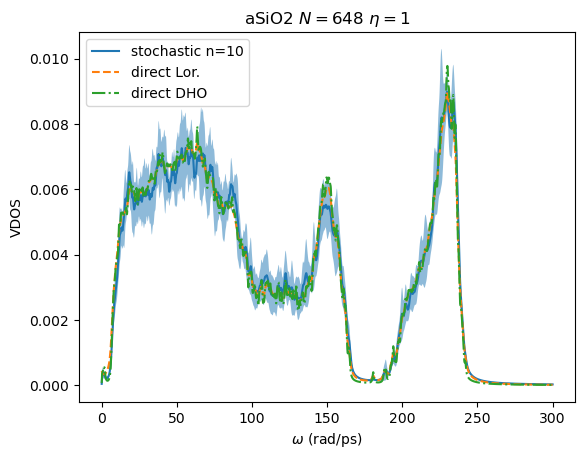

In [9]:
w_true=np.sign(w2)*np.sqrt(np.abs(w2))
fig,ax=plt.subplots()
w=spectrum['omega']
y=np.mean(np.array([w*spectrum[i]['S'] for i in range(nstoc)]),axis=0)
yerr=np.std(np.array([w*spectrum[i]['S'] for i in range(nstoc)]),axis=0)
norm=np.trapz(y, w)
y/=norm
yerr/=norm
ax.plot(w,y,label='stochastic n={}'.format(nstoc))
ax.fill_between(w,y+yerr,y-yerr,alpha=0.5)
vdos=compute_vdos(w_true,w,sigma=eta,kernel='lorentz')
ax.plot(w,vdos,'--',label='direct Lor.')
vdos=compute_vdos(w_true,w,sigma=eta,kernel='DHO')
ax.plot(w,vdos,'-.',label='direct DHO')
plt.title('aSiO2 $N=648$ $\eta={}$'.format(eta) )
plt.legend()
plt.ylabel('VDOS')
plt.xlabel('$\omega\mathrm{~(rad/ps)}$')
plt.show()
